# 一、核心概念：什么是前馈神经网络？
## 1.1 基本定义
前馈神经网络是一种信息单向流动的网络：数据从输入层 → 隐藏层 → 输出层，没有循环或反馈连接。
- 在 Transformer 的语境下，FFN 通常指位置前馈网络（Position-wise Feed-Forward Network），它对序列中的每个位置独立应用相同的全连接网络。
## 1.2 为什么需要 FFN？
自注意力层主要负责捕捉序列中不同位置之间的关系，但它本身是线性变换（点积 + 加权平均）。FFN 的作用是：

| 作用         | 说明                          |
| ---------- | --------------------------- |
| **引入非线性**  | 让模型学习更复杂的函数映射               |
| **特征变换**   | 将注意力层的输出映射到更高维空间，再压缩回来      |
| **增加表达能力** | 没有 FFN，Transformer 只是一组线性操作 |


# 二、Transformer 中的 FFN 结构
## 2.1 标准公式
- FFN(x)=$ReLU(xW_1+b_1)W_2+b2$   
或用更现代的激活函数（如 GELU）：
- FFN(x)=$GELU(xW_1+b_1)W_2+b_2  $
## 2.2 网络结构图

In [ ]:
输入 x (维度: d_model)
    │
    ▼
┌─────────────────┐
│  第一层线性变换  │  xW₁ + b₁
│  (升维)         │  输出维度: d_ff (通常 d_ff = 4 × d_model)
└─────────────────┘
    │
    ▼
┌─────────────────┐
│   激活函数      │  ReLU/GELU/SiLU 等
│  (引入非线性)   │
└─────────────────┘
    │
    ▼
┌─────────────────┐
│  第二层线性变换  │  (激活输出)W₂ + b₂
│  (降维)         │  输出维度: d_model
└─────────────────┘
    │
    ▼
输出 (维度: d_model)

## 2.3 关键超参数

| 参数          | 典型值                | 说明                             |
| ----------- | ------------------ | ------------------------------ |
| $d_{model}$ | 512 / 768 / 1024   | 模型隐藏层维度                        |
| $d_{ff}$    | 2048 / 3072 / 4096 | 中间层维度，通常为 $4 \times d_{model}$ |
| 激活函数        | GELU / ReLU        | 引入非线性                          |

# 三、详细计算例子


In [1]:
from IPython.display import Image

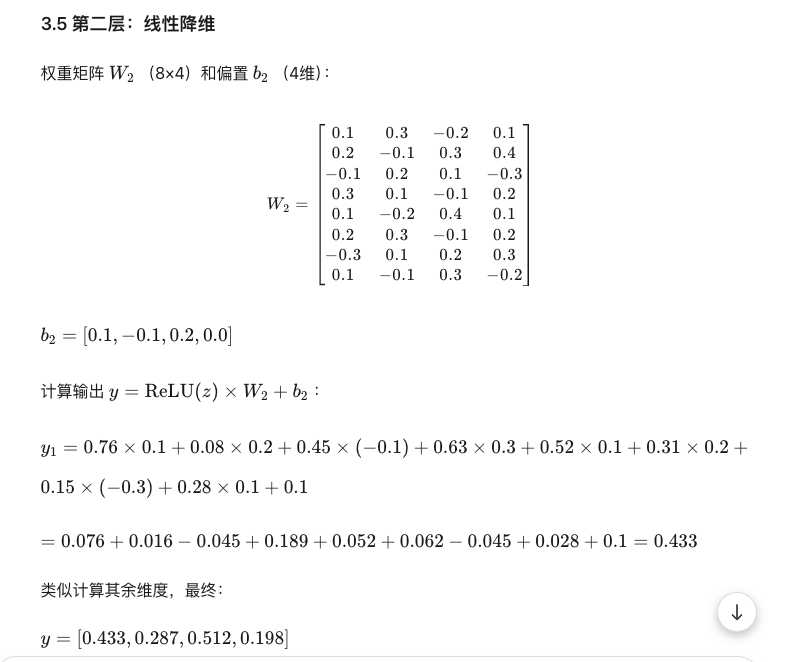

In [2]:
Image(filename='a1.png')

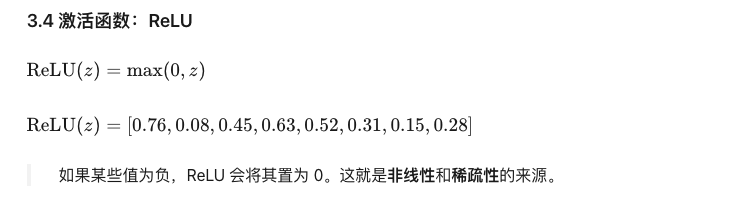

In [3]:
Image(filename='a2.png')

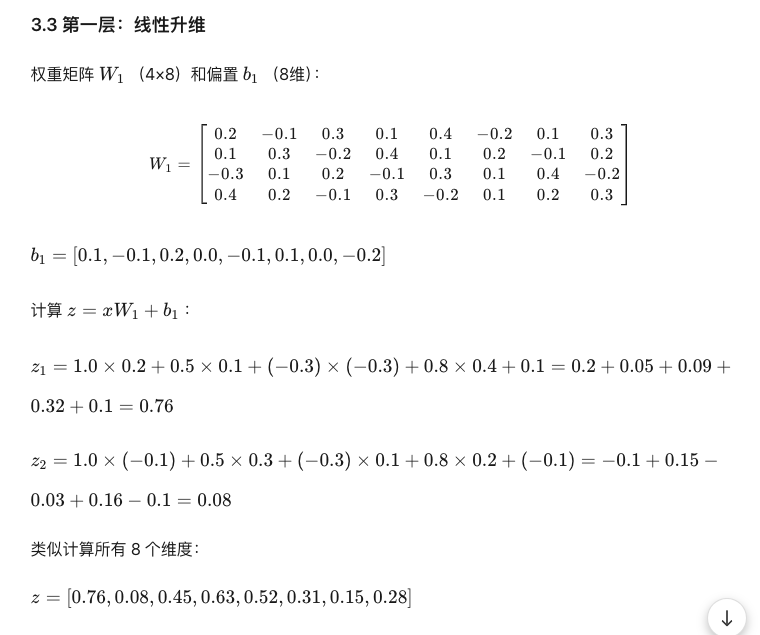

In [4]:
Image(filename='a3.png')

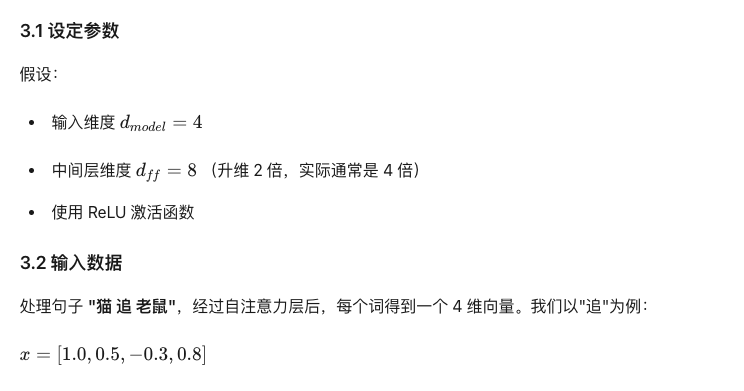

In [5]:
Image(filename='a4.png')

# 四、FFN 的深层作用解析
## 4.1 为什么先升维再降维？

In [ ]:
低维空间 (d_model)          高维空间 (d_ff)           低维空间 (d_model)
    [4维]        ──升维──→      [8维]       ──降维──→      [4维]
   信息压缩                      信息展开                      精炼提取
   (线性可分性弱)               (线性可分性强)                (非线性特征)

类比：就像榨果汁
- 原始水果（低维）：信息混杂在一起
- 压榨分离（升维）：将不同成分分开到更大空间
- 调配混合（降维）：按需要重新组合，提取精华
## 4.2 非线性激活的关键作用
如果没有激活函数，FFN 就退化为两层线性变换：
- FFN(x)=$(xW_1+b_1)W_2+b_2 = x(W_1W_2)+(b_1W_2+b_2)=xW^`+b^` $
  
两层线性 = 一层线性，完全失去了增加层数的意义！
ReLU/GELU 等激活函数打破了这种线性，让网络可以逼近任意复杂函数（万能逼近定理）。

# 五、现代变体：SwiGLU FFN
目前主流大模型（如 LLaMA、PaLM）使用 SwiGLU 替代标准 FFN：
SwiGLU(x)=$(Swish(xW_1)⊗xW_2)W_3$

## 结构：

In [ ]:
输入 x
    │
    ├──→ xW₁ ──→ Swish激活 ──┐
    │                          ├──→ 逐元素相乘 ──→ xW₃ ──→ 输出
    └──→ xW₂ ────────────────┘

## 优势：
- Swish 激活更平滑，梯度传播更好
- 门控机制（类似 LSTM 的门）动态控制信息流动
- 实验效果优于 ReLU/GELU

# 六、完整流程可视化

In [ ]:
句子: "猫 追 老鼠"

自注意力层输出:
  猫' = [0.8, 0.3, 0.1, 0.5]
  追' = [1.0, 0.5, -0.3, 0.8]  ← 以这个词为例
  老鼠' = [0.2, 0.9, 0.4, 0.1]

        ↓ 对每个位置独立应用 FFN

┌─────────────────────────────────────┐
│  FFN(追') = ReLU(追'W₁ + b₁)W₂ + b₂ │
│                                     │
│  [1.0, 0.5, -0.3, 0.8]              │
│       ↓                             │
│  升维: [0.76, 0.08, 0.45, 0.63,     │
│         0.52, 0.31, 0.15, 0.28]     │
│       ↓                             │
│  ReLU: [0.76, 0.08, 0.45, 0.63,     │
│         0.52, 0.31, 0.15, 0.28]     │
│       ↓                             │
│  降维: [0.433, 0.287, 0.512, 0.198] │
└─────────────────────────────────────┘

FFN 层输出:
  猫'' = [0.312, 0.445, 0.128, 0.667]
  追'' = [0.433, 0.287, 0.512, 0.198]  ← 非线性变换后的新表示
  老鼠'' = [0.551, 0.123, 0.389, 0.234]

        ↓ 残差连接 + LayerNorm

  最终输出（进入下一个 Transformer 层）

# 七、关键要点总结

| 要点        | 说明                                          |
| --------- | ------------------------------------------- |
| **位置独立**  | 每个 token 的 FFN 计算互不干扰，可并行                   |
| **升维降维**  | $d_{ff} \approx 4 \times d_{model}$ 是经验最优比例 |
| **非线性核心** | 激活函数是 FFN 的灵魂，没有它网络将退化                      |
| **参数占比大** | FFN 参数量约占 Transformer 总参数的 2/3              |
| **现代演进**  | SwiGLU 已成为大模型的标准配置                          |

- FFN 虽然结构简单，但它是 Transformer 从"关系建模"（自注意力）走向"深度特征学习"的关键桥梁。没有 FFN，Transformer 只能做加权平均；有了 FFN，它才能学习复杂的语言规律。